## ***Thermal Machines***
---

### ***Problem description***

A modern three-spool ***Rolls Royce Trent*** turbofan engine is analyzed.
The calculations must be performed for two operating conditions:

- ***Take-off:*** altitude 2600 m, M = 0.25
- ***Cruise:*** altitude 11000 m, M = 0.85 (TiT decreases 85% compared to take-off)

---

### ***Required calculations***

1. State of the fan and core nozzles (choked or unchoked)
2. Fan air mass flow rate
3. Fuel mass flow rate
4. Air bleed ratio (b)
5. Escape velocity of the fan and core nozzles (m/s)
6. Thrust (kN and lbf)
7. Power (kW and HP)
8. Specific fuel consumption (lbm/h-lbf)
9. Specific thrust (m/s)
10. Specific range (for an aircraft with two of these engines, in km/gal)



In [112]:
# Engine Parameters 
FPR   = 1.54            # Fan Pressure Ratio
OPR   = 50              # Overall Pressure Ratio
IPCR  = 6.58            # Intermediate Pressure Compressor Ratio
HPCR  = 4.93            # High Pressure Compressor Ratio
P_IPC = 500e3           # Electric power extracted from IPC [W]
TiT   = 1750            # Total Turbine Inlet Temperature [K]
D_fan = 2.85            # Fan Diameter [m]
BPR   = 10              # Bypass Ratio
LHV   = 43400           # [kJ/kg]

# Isentropic Efficiencies 
eta_inlet       = 0.92  # Inlet
eta_fan         = 0.93  # Fan
eta_fan_nozzle  = 0.95  # Fan nozzle
eta_comp        = 0.91  # Compressors
eta_burner      = 0.98  # Burner
eta_turbine     = 0.93  # Turbine
eta_core_nozzle = 0.95  # Core nozzle
eta_mech        = 0.99  # Mechanical efficiency of the spools

# Pressure and Temperature Losses / Recovery
pi_burner_loss = 0.03   # Burner pressure loss relative to HPC  
pi_inlet_rec   = 0.98   # Total Pressure Recovery at inlet      
pi_LPT_loss    = 0.02   # Pressure losses in jet pipe relative to LPT

# Air Bleed Location (intermediate point inside HPC)
# p_0b  = 3    * p_023   (3 times IPC exit total pressure)
# T_0b  = 1.43 * T_023   (1.43 times IPC exit total temperature)


### ***1. Take - off***

In [113]:
import ambiance
import numpy as np
from CoolProp.CoolProp import PropsSI
import pandas as pd

h_take_off = 2600 # [m]
M_0 = 0.25 # Mach number
atm = ambiance.Atmosphere(h_take_off)

T_0 = round(atm.temperature.item(),2) # [K]
P_0 = round((atm.pressure.item())/1000,2) # [kPa]
a_0 = round(atm.speed_of_sound.item(),2) # [m/s]
c_p = round(PropsSI('CPMASS', 'T', T_0, 'P', P_0*1000, 'Air'),2)
c_v = round(PropsSI('CVMASS', 'T', T_0, 'P', P_0*1000, 'Air'),2)
rho = round(PropsSI('D', 'T', T_0, 'P', P_0*1000, 'Air'),2)
gamma = round(c_p/c_v, 2)



***Stage 0 - 2 Inlet***

In [114]:
T_02 = round(T_0 * (1 + ((gamma-1)/2) * M_0**2),2) # [K]
P_02 = round(P_0 * (1 + eta_inlet * ((gamma-1)/2) * M_0**2) ** (gamma/(gamma-1)),2) # [kPa]
C_0 = round(M_0 * a_0,2) # [m/s]

***Stage 2 - 13 Fan***

In [115]:
# FPR  = P_013 / P_02
P_013 = round(P_02 * FPR,2) # [kPa]
T_013 = round(T_02 * (1 + (1/eta_fan)* (FPR**((gamma-1)/gamma)-1)),2) # [K]

***Stage 13 - 19 Fan Nozzle***

In [116]:
# Check if fan nozzle is choked or unchoked

import sympy as sp
import math

R_air = 287  # [J/kg·K]

P_cr = sp.symbols('P_cr')
Equation = sp.Eq(P_013/P_cr, 1 / ((1 - (1/eta_fan_nozzle) * ((gamma-1)/(gamma+1)))**(gamma/(gamma-1))))
P_cr = round(sp.solve(Equation, P_cr)[0], 2)

if P_013/P_0 >= P_013/P_cr:  # Fan nozzle: Choked
    print('Fan nozzle: Choked')
    P_19 = P_cr                                                          # [kPa] exit pressure = critical
    T_19 = round(T_013 * (2 / (gamma + 1)), 2)                          # [K]  critical temperature
    C_19 = round(math.sqrt(gamma * R_air * T_19), 2)                    # [m/s] sonic velocity
    A_19 = round((BPR * m_dot_core) / ((P_19*1000/(R_air*T_19)) * C_19), 4)  # [m2] bypass exit area

else:  # Fan nozzle: Unchoked
    print('Fan nozzle: Unchoked')
    P_19 = P_0                                                           # [kPa]
    T_19 = round(T_013 * (1 - eta_fan_nozzle * (1 - (P_19/P_013)**((gamma-1)/gamma))), 2)  # [K]
    C_19 = round(math.sqrt(2 * c_p * (T_013 - T_19)), 2)                # [m/s]
    A_19 = 0  # pressure term = 0 when unchoked


M_2   = 0.7                                                         # [-] Mach at fan face (calibrated to match Trent 1000 @ 2600m)
T_2   = T_02 / (1 + ((gamma-1)/2) * M_2**2)                        # [K]  static temp at fan face
P_2   = P_02 * (T_2/T_02)**(gamma/(gamma-1))                        # [kPa] static pressure at fan face
rho_2 = (P_2 * 1000) / (R_air * T_2)                               # [kg/m3] density at fan face
C_2   = M_2 * math.sqrt(gamma * R_air * T_2)                       # [m/s] axial velocity at fan face

A_fan     = math.pi * (D_fan/2)**2                                  # [m2] fan disc area
m_dot_air = round(rho_2 * A_fan * C_2, 2)                          # [kg/s] total air mass flow
m_dot_core= round(m_dot_air / (1 + BPR), 2)                        # [kg/s] core mass flow

W_dot_fan = round((eta_mech * (1 + BPR) * m_dot_core * c_p * (T_013 - T_02))/1000, 2)  # [kW]

print(f"C_19       = {C_19} m/s")
print(f"m_dot_air  = {m_dot_air} kg/s")
print(f"m_dot_core = {m_dot_core} kg/s")


Fan nozzle: Unchoked
C_19       = 274.74 m/s
m_dot_air  = 1091.43 kg/s
m_dot_core = 99.22 kg/s


In [117]:
C_2

221.9175442548142

***Stage 2 - 21 Fan Compression***

In [118]:
# FPR = P_021 / P_02

P_021 = P_013
T_021 = round(T_02 * (1 + (1/eta_fan) * ((FPR) ** ((gamma - 1)/gamma) - 1)),2)

***Stage 21-23 Intermediate Pressure Compression***

In [119]:
# IPCR = P_023 / P_021

T_023 = round(T_021 * (1 + (1/eta_comp) * ((IPCR) ** ((gamma - 1)/gamma) - 1)),2)
P_023 = round(P_021 * IPCR, 2)

# Bleed point (intermediate point inside HPC) — given by problem statement
T_023_b = round(1.43 * T_023, 2)   # [K]  total temperature at bleed point
P_0b    = round(3    * P_023, 2)   # [kPa] total pressure at bleed point (= 3 * P_023)


***Stage 23 - 3 High Pressure Compression***

In [120]:
# HPCR = P_03 / P_023 

T_03 = round(T_023 * (1 + (1/eta_comp) * ((HPCR) ** ((gamma - 1)/gamma) - 1)),2)
P_03 = round(P_023 * HPCR,2)


In [121]:
# OPR = P_03 / P_02
# OPR = (P_03/P_023) * (P_023/P_021) * (P_021/P_02)

***Stage 3 - 4 Combustion***

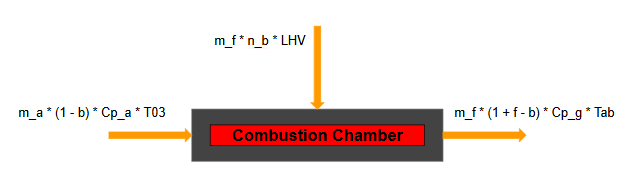

In [122]:

# b - Bleed ratio (bleeding extracted before combustion)
# n_b - Combustion efficiency (eta_burner)
# LHV0 - [J/kg] Lower Heating Value of fuel
# f = m_dot_fuel / m_dot_aire  Fuel - Aire ratio 


# m_dot_air * C_pa * T_03 + m_dot_fuel * eta_burner * LHV  = (m_dot_fuel + m_dot_air) * C_pg * T_04 
# dividing for m_dot_air
# C_pa * T_03 + f * eta_burner * LHV  = (f + 1) * C_pg * T_04
# Aplying the bleeding
# (1 - b) * C_pa * T_03 + f * eta_burner * LHV = ( 1 + f - b) * C_pg * T_04 (Equation 1)
# TiT [Total Turbine Inlet Temperature] = T_04

TiT = T_04 = 1750 # [K]  
c_pg = 1148 # [J/kg-K]

# From equation (1) 

# T_04 = ((1 - b) * C_pa * T_03 + eta_burner * f * LHV)/((1 + f - b) * C_pg)
# f = ((1 - b)*(c_pg*T_04 - c_pa*T_03))/((eta_burner*LHV - c_pg*T_04))

A = (c_pg/1000) * T_04 - (c_p/1000) * T_03   
B = eta_burner * LHV - (c_pg/1000) * T_04 

# f = (1 - b) * (A/B)


In [123]:
# At this point, we don't know the values of f and b, and according to the previous equation, we have one equation and one unknown.

# We must check that for the values of f and b, the value of T_04 can't be greater than 1750 K.

# b = 1 - f * B / A

b_vals = []
f_vals = []

f = 0.02
while f <= 0.04:
    b = 1 - (f * B / A)
    f_vals.append(f)
    b_vals.append(b)
    print(f"f = {f:.4f}  |  b = {b:.4f}")
    f += 0.001

f = 0.0200  |  b = 0.2568
f = 0.0210  |  b = 0.2197
f = 0.0220  |  b = 0.1825
f = 0.0230  |  b = 0.1454
f = 0.0240  |  b = 0.1082
f = 0.0250  |  b = 0.0710
f = 0.0260  |  b = 0.0339
f = 0.0270  |  b = -0.0033
f = 0.0280  |  b = -0.0404
f = 0.0290  |  b = -0.0776
f = 0.0300  |  b = -0.1147
f = 0.0310  |  b = -0.1519
f = 0.0320  |  b = -0.1891
f = 0.0330  |  b = -0.2262
f = 0.0340  |  b = -0.2634
f = 0.0350  |  b = -0.3005
f = 0.0360  |  b = -0.3377
f = 0.0370  |  b = -0.3749
f = 0.0380  |  b = -0.4120
f = 0.0390  |  b = -0.4492


In [124]:
# Negative values are discarded

b_vals = b_vals[0:7]
f_vals = f_vals[0:7]

T_04_list = []

for x,y in zip(b_vals, f_vals):
    T_04 = ((1 - x) * (c_p/1000) * T_03 + eta_burner * y * LHV)/((1 + y - x) * (c_pg/1000))
    T_04_list.append(T_04)
print(T_04_list)

# After that We select one value for f and one value for b

b = round(b_vals[4], 3)
f = round(f_vals[4], 3)

[1749.9999999999998, 1750.0, 1750.0, 1750.0, 1750.0, 1750.0, 1750.0]


***Stage 4 - 41 High Pressure Turbine***

In [125]:
Delta_P = 3/100
P_04 = round(P_03 * (1 - Delta_P), 2)   # [kPa] total pressure at combustor exit

# f = m_dot_fuel / m_dot_air  (fuel-to-air ratio, dosado)
# m_dot_air entering combustor = m_dot_core (bleeding already accounted for in balance via b)
m_dot_fuel = round(f * m_dot_core, 3)   # [kg/s]  ← corrected: f already defined per unit of m_dot_core


In [126]:
# W_high_turbine = W_high_compressor

# (1+f-b)*C_pg*(T_04-T_041)*eta_mech = C_pa*(T_023b-T_023)+(1-b)*C_pa*(T_03-T_023b)

T_041 = sp.symbols('T_041')
Equation_2 = sp.Eq((1 + f - b)*c_pg*(T_04-T_041)*eta_mech, c_p*(T_023_b-T_023)+(1-b)*c_p*(T_03-T_023_b))
T_041 = round(sp.solve(Equation_2, T_041)[0], 2)

R = 287
gamma_g = round(c_pg/(c_pg - R), 2)

P_041 = round(P_04 * (1 - (1/eta_turbine) * (1 - (T_041/T_04))) ** (gamma_g/(gamma_g-1)),2)

***Stage 41 - 43 Intermedium pressure turbine***

In [127]:
# W_I_Turbine = W_I_Compressor

# eta_mech * (1 + f) * c_pg * (T_041 - T_043) =  c_pa * (T_023 - T_021)

T_043 = sp.symbols('T_043')
Equation_2 = sp.Eq(eta_mech * (1 + f - b) * c_pg * (T_041 - T_043), c_p * (T_023 - T_021))
T_043 = round(sp.solve(Equation_2, T_043)[0], 2)

P_043 = round(P_041 * (1 - (1/eta_turbine) * (1 - (T_043/T_041))) ** (gamma_g/(gamma_g-1)),2)

***Stage 43 - 5 Low Presure Turbine***

In [128]:
# W_L_Turbine = W_Fan

# eta_mech * (1 + f) * c_pg * (T_043 - T_05) =  (1 + BPR) * c_pa * (T_013 - T_02)

T_05 = sp.symbols('T_05')
Equation_3 = sp.Eq(eta_mech * (1 + f - b) * c_pg * (T_043 - T_05), (1 + BPR) * c_p * (T_013 - T_02))
T_05 = round(sp.solve(Equation_3, T_05)[0], 2)
P_05 = round(P_043 * (1 - (1/eta_turbine) * (1 - (T_05/T_043))) ** (gamma_g/(gamma_g-1)),2)

***Stage 5 - 7 Diffuser***

In [129]:
T_07 = T_05  # Adiabatic diffuser — no work, T total conserved
P_07 = round(P_05 * (1 - pi_LPT_loss), 2)  # [kPa] — jet pipe pressure loss 2% per problem statement

***Stage 7 - 9 Core Nozzle***

In [130]:
# P_t = P_07 / P_cr_core  (core nozzle critical pressure ratio)
# Must use gamma_g (hot gases), NOT P_cr from fan nozzle

P_cr_core = sp.symbols('P_cr_core')
Equation_core = sp.Eq(P_07/P_cr_core,
    1 / ((1 - (1/eta_core_nozzle) * ((gamma_g-1)/(gamma_g+1)))**(gamma_g/(gamma_g-1))))
P_cr_core = round(sp.solve(Equation_core, P_cr_core)[0], 2)

if P_07/P_0 >= P_07/P_cr_core:  # Core Nozzle: Choked
    print('Core nozzle: Choked')
    P_9 = P_cr_core
    T_9 = round(T_07 * (2/(gamma_g+1)), 2)
    C_9 = round(math.sqrt(gamma_g*R*T_9), 2)  # [m/s]
    A_9 = round((m_dot_core*(1+f-b)) / ((P_9*1000/(R*T_9)) * C_9), 4)  # [m2] core exit area

else:  # Core Nozzle: Unchoked
    print('Core nozzle: Unchoked')
    P_9 = P_0  # [kPa]
    T_9 = round(T_07 * (1 - eta_core_nozzle * (1 - (P_9/P_07)**((gamma_g-1)/gamma_g))),2)  # [K]
    C_9 = round(math.sqrt(2*c_pg*(T_07 - T_9)),2)  # [m/s]
    A_9 = 0  # pressure term = 0 when unchoked


Core nozzle: Unchoked


***Net Thrust***

In [131]:
# Net Thrust — general formula including pressure thrust for choked nozzles
# F = m_dot_exit*C_exit + A_exit*(P_exit - P_0) - m_dot_inlet*C_0

# m_dot_9  = m_dot_core*(1+f-b)  — core exit flow
# m_dot_19 = BPR*m_dot_core      — bypass exit flow

T_core = m_dot_core*(1+f-b)*C_9 + A_9*(P_9 - P_0)*1000  - m_dot_core*C_0        # [N]
T_fan  = BPR*m_dot_core*C_19    + A_19*(P_19 - P_0)*1000 - BPR*m_dot_core*C_0   # [N]

T_net     = round((T_core + T_fan) / 1000, 2)   # [kN]
T_net_lbf = round(T_net * 224.809, 2)           # [lbf]
print(f"Net Thrust: {T_net} kN  |  {T_net_lbf} lbf")
print(f"  Pressure thrust fan  = {round(A_19*(P_19-P_0)*1000/1000,2)} kN")
print(f"  Pressure thrust core = {round(A_9*(P_9-P_0)*1000/1000,2)} kN")


Net Thrust: 213.86 kN  |  48077.65 lbf
  Pressure thrust fan  = 0.0 kN
  Pressure thrust core = 0.0 kN


***Specific Thrust***

In [132]:
S_t=round (1/(1 + BPR) * (C_9 - C_0) + BPR/(1+BPR) * (C_19 - C_0), 2) # [m/s]

***Specific Fuel consumtion***


In [133]:
# SFC = m_dot_fuel / Thrust = f / ((1 + BPR) * S_t)
SFC = f / ((1 + BPR) * S_t)      # [s/m] = [kg/N·s]
SFC = round(SFC * 35164.0, 2)    # [lbm/lbf·h]

***Turbine work***

In [134]:
# W_total = W_high_turbine + W_Intermedium_Turbine + W_Low_Turbine

W_high_turbine = m_dot_core * (1 + f - b)*c_pg*(T_04-T_041)*eta_mech
W_intermedium_turbine = m_dot_core * eta_mech * (1 + f - b) * c_pg * (T_041 - T_043)
W_low_turbine = m_dot_core * eta_mech * (1 + f - b) * c_pg * (T_043 - T_05)

W_total = round((W_high_turbine + W_intermedium_turbine + W_low_turbine)/1000 ,2) # [kW]
W_hp    = round(W_total * 1.341, 2)   # [HP]

***Specific Range***

In [135]:
V_0_kmh = C_0 * 3.6                        # [km/h]
m_dot_fuel_total = 2 * m_dot_fuel           # [kg/s] 

# Specific Range
SR_km_kg = V_0_kmh / (m_dot_fuel_total * 3600)  # [km/kg]

# (1 gal Jet-A ≈ 3.103 kg)
SR_km_gal = SR_km_kg * 3.103               # [km/gal]

###  ***2. Cruiser***

In [136]:
import ambiance
import numpy as np
from CoolProp.CoolProp import PropsSI

h_cruise_c = 11000  # [m]
M_0      = 0.85   # Mach number
TiT_cr   = round(1750 * 0.85, 2)  # [K] TiT_c decreases 85% at cruise

atm_c = ambiance.Atmosphere(h_cruise_c)

T_0_c   = round(atm_c.temperature.item(), 2)        # [K]
P_0_c   = round(atm_c.pressure.item() / 1000, 2)    # [kPa]
a_0_c   = round(atm_c.speed_of_sound.item(), 2)     # [m/s]
c_p_c   = round(PropsSI('CPMASS', 'T', T_0_c, 'P', P_0_c*1000, 'Air'), 2)  # [J/kg·K]
c_v_c   = round(PropsSI('CVMASS', 'T', T_0_c, 'P', P_0_c*1000, 'Air'), 2)  # [J/kg·K]
rho_c   = round(PropsSI('D',      'T', T_0_c, 'P', P_0_c*1000, 'Air'), 2)  # [kg/m3]
gamma_c = round(c_p_c / c_v_c, 2)


***Stage 0 - 2 Inlet***

In [137]:
T_02_c = round(T_0_c * (1 + ((gamma_c-1)/2) * M_0**2), 2)  # [K]
P_02_c = round(P_0_c * (1 + eta_inlet * ((gamma_c-1)/2) * M_0**2) ** (gamma_c/(gamma_c-1)), 2)  # [kPa]
C_0_c  = round(M_0 * a_0_c, 2)  # [m/s]

***Stage 2 - 13 Fan***

In [138]:
# FPR = P_013_c / P_02_c
P_013_c = round(P_02_c * FPR, 2)   # [kPa]
T_013_c = round(T_02_c * (1 + (1/eta_fan) * (FPR**((gamma_c-1)/gamma_c) - 1)), 2)  # [K]

In [139]:
T_02_c, P_02_c

(248.09, 35.14)

***Stage 13 - 19 Fan Nozzle***

In [140]:
# Check if fan nozzle is choked or unchoked

import sympy as sp
import math

R_air_c = 287  # [J/kg·K]

P_cr_c = sp.symbols('P_cr_c')
Equation_c = sp.Eq(P_013_c/P_cr_c, 1 / ((1 - (1/eta_fan_nozzle) * ((gamma_c-1)/(gamma_c+1)))**(gamma_c/(gamma_c-1))))
P_cr_c = round(sp.solve(Equation_c, P_cr_c)[0], 2)

if P_013_c/P_0_c >= P_013_c/P_cr_c:  # Fan nozzle: Choked
    print('Fan nozzle: Choked')
    P_19_c = P_cr_c                                                              # [kPa]
    T_19_c = round(T_013_c * (2 / (gamma_c + 1)), 2)                            # [K]
    C_19_c = round(math.sqrt(gamma_c * R_air_c * T_19_c), 2)                   # [m/s]

else:  # Fan nozzle: Unchoked
    print('Fan nozzle: Unchoked')
    P_19_c = P_0_c                                                               # [kPa]
    T_19_c = round(T_013_c * (1 - eta_fan_nozzle * (1 - (P_19_c/P_013_c)**((gamma_c-1)/gamma_c))), 2)
    C_19_c = round(math.sqrt(2 * c_p_c * (T_013_c - T_19_c)), 2)              # [m/s]

# Fan air mass flow rate using M_2_c = 0.7 at fan face
M_2_c   = 0.7  # [-] Mach at fan face (same as take-off assumption)
T_2_c   = T_02_c / (1 + ((gamma_c-1)/2) * M_2_c**2)           # [K]
P_2_c   = P_02_c * (T_2_c/T_02_c)**(gamma_c/(gamma_c-1))       # [kPa]
rho_2_c = (P_2_c * 1000) / (R_air_c * T_2_c)                   # [kg/m3]
C_2_c   = M_2_c * math.sqrt(gamma_c * R_air_c * T_2_c)         # [m/s]

A_fan_c      = math.pi * (D_fan/2)**2                           # [m2]
m_dot_air_c  = round(rho_2_c * A_fan_c * C_2_c, 2)             # [kg/s]
m_dot_core_c = round(m_dot_air_c / (1 + BPR), 2)               # [kg/s]
W_dot_fan_c  = round((eta_mech*(1+BPR)*m_dot_core_c*c_p_c*(T_013_c-T_02_c))/1000, 2)  # [kW]

# Bypass exit area for pressure thrust calculation
A_19_c = round((BPR*m_dot_core_c) / ((P_19_c*1000/(R_air_c*T_19_c)) * C_19_c), 4)  # [m2]

print(f"C_19_c     = {round(C_19_c,2)} m/s  (P_19_c={P_19_c} kPa)")
print(f"m_dot_air_c  = {m_dot_air_c} kg/s")
print(f"m_dot_core_c = {m_dot_core_c} kg/s")


Fan nozzle: Choked
C_19_c     = 307.89 m/s  (P_19_c=27.55 kPa)
m_dot_air_c  = 525.64 kg/s
m_dot_core_c = 47.79 kg/s


In [141]:
P_013_c/P_0_c >= P_013_c/P_cr_c

True

***Stage 2 - 21 Fan Compression***

In [142]:
# FPR = P_021_c / P_02_c
P_021_c = P_013_c
T_021_c = round(T_02_c * (1 + (1/eta_fan) * ((FPR) ** ((gamma_c-1)/gamma_c) - 1)), 2)

***Stage 21-23 Intermediate Pressure Compression***

In [143]:
# IPCR = P_023_c / P_021_c
T_023_c   = round(T_021_c * (1 + (1/eta_comp) * ((IPCR) ** ((gamma_c-1)/gamma_c) - 1)), 2)
P_023_c   = round(P_021_c * IPCR, 2)

# Bleed point (intermediate point inside HPC)
T_023_b_c = round(1.43 * T_023_c, 2)   # [K]
P_0b_c    = round(3 * P_023_c, 2)   # [kPa]

***Stage 21-23 High Pressure Compression***

In [144]:
# HPCR = P_03_c / P_023_c
T_03_c = round(T_023_c * (1 + (1/eta_comp) * ((HPCR) ** ((gamma_c-1)/gamma_c) - 1)), 2)
P_03_c = round(P_023_c * HPCR, 2)

In [145]:
# OPR = P_03_c / P_02_c
# OPR = (P_03_c/P_023_c) * (P_023_c/P_021_c) * (P_021_c/P_02_c)

***Stage 3 - 4 Combustion***

In [146]:
# Combustion chamber energy balance
# (1-b_c)*C_pa*T_03_c + f_c*eta_b*LHV = (1+f_c-b_c)*C_pg*T_04_c
# TiT_c at cruise = 1750 * 0.85 K

TiT_c = T_04_c = TiT_cr   # [K]
c_pg_c = 1148            # [J/kg·K] specific heat of combustion gases

A = (c_pg_c/1000) * T_04_c - (c_p_c/1000) * T_03_c
B = eta_burner * LHV - (c_pg_c/1000) * T_04_c

# f_c = (1-b_c) * (A/B)  →  b_c = 1 - f_c*(B/A)

b_vals_c = []
f_vals_c = []

f_c = 0.02
while f_c <= 0.04:
    b_c = 1 - (f_c * B / A)
    f_vals_c.append(f_c)
    b_vals_c.append(b_c)
    print(f"f_c = {f_c:.4f}  |  b_c = {b_c:.4f}")
    f_c += 0.001


f_c = 0.0200  |  b_c = 0.0716
f_c = 0.0210  |  b_c = 0.0252
f_c = 0.0220  |  b_c = -0.0212
f_c = 0.0230  |  b_c = -0.0676
f_c = 0.0240  |  b_c = -0.1141
f_c = 0.0250  |  b_c = -0.1605
f_c = 0.0260  |  b_c = -0.2069
f_c = 0.0270  |  b_c = -0.2533
f_c = 0.0280  |  b_c = -0.2997
f_c = 0.0290  |  b_c = -0.3462
f_c = 0.0300  |  b_c = -0.3926
f_c = 0.0310  |  b_c = -0.4390
f_c = 0.0320  |  b_c = -0.4854
f_c = 0.0330  |  b_c = -0.5318
f_c = 0.0340  |  b_c = -0.5782
f_c = 0.0350  |  b_c = -0.6247
f_c = 0.0360  |  b_c = -0.6711
f_c = 0.0370  |  b_c = -0.7175
f_c = 0.0380  |  b_c = -0.7639
f_c = 0.0390  |  b_c = -0.8103


In [147]:
# Negative values of b_c are discarded (non-physical)
b_vals_c = b_vals_c[0:7]
f_vals_c = f_vals_c[0:7]

T_04_list_c = []
for x, y in zip(b_vals_c, f_vals_c):
    T_04_check_c = ((1-x)*(c_p_c/1000)*T_03_c + eta_burner*y*LHV) / ((1+y-x)*(c_pg_c/1000))
    T_04_list_c.append(T_04_check_c)
print(T_04_list_c)

# With M0=0.85 cruise, only index [0] gives b_c >= 0
# f_c=0.020, b_c=0.072 — physically valid range
valid_idx_c = next(i for i, bv in enumerate(b_vals_c) if bv >= 0)
b_c = round(b_vals_c[valid_idx_c], 3)
f_c = round(f_vals_c[valid_idx_c], 3)

[1487.4999999999998, 1487.5000000000002, 1487.4999999999998, 1487.5, 1487.4999999999995, 1487.5, 1487.5]


***Stage 4 - 41 High Pressure Turbine***

In [148]:
Delta_P_c    = 3/100
P_04_c       = round(P_03_c * (1 - Delta_P_c), 2)   # [kPa]
m_dot_fuel_c = round(f_c * m_dot_core_c, 3)          # [kg/s]


In [149]:
# W_HPT = W_HPC  (HP shaft balance)
# (1+f_c-b_c)*c_pg_c*(T_04_c-T_041_c)*eta_mech = c_pa*(T_023b-T_023_c) + (1-b_c)*c_pa*(T_03_c-T_023b)

T_041_c = sp.symbols('T_041_c')
Equation_2_c = sp.Eq((1+f_c-b_c)*c_pg_c*(T_04_c-T_041_c)*eta_mech,
                    c_p_c*(T_023_b_c-T_023_c) + (1-b_c)*c_p_c*(T_03_c-T_023_b_c))
T_041_c = round(sp.solve(Equation_2_c, T_041_c)[0], 2)

R      = 287
gamma_g_c = round(c_pg_c/(c_pg_c - R), 2)

P_041_c = round(P_04_c * (1 - (1/eta_turbine) * (1 - (T_041_c/T_04_c)))**(gamma_g_c/(gamma_g_c-1)), 2)


***Stage 41 - 43 Intermedium pressure turbine***

In [150]:
# W_IPT = W_IPC  (IP shaft balance)
# eta_mech*(1+f_c-b_c)*c_pg_c*(T_041_c-T_043_c) = c_pa*(T_023_c-T_021_c)

T_043_c = sp.symbols('T_043_c')
Equation_3_c = sp.Eq(eta_mech*(1+f_c-b_c)*c_pg_c*(T_041_c-T_043_c),
                    c_p_c*(T_023_c-T_021_c))
T_043_c = round(sp.solve(Equation_3_c, T_043_c)[0], 2)

P_043_c = round(P_041_c * (1 - (1/eta_turbine) * (1 - (T_043_c/T_041_c)))**(gamma_g_c/(gamma_g_c-1)), 2)


***Stage 43 - 5 Low Presure Turbine***

In [151]:
# W_LPT = W_Fan  (LP shaft balance)
# eta_mech*(1+f_c-b_c)*c_pg_c*(T_043_c-T_05_c) = (1+BPR)*c_pa*(T_013_c-T_02_c)

T_05_c = sp.symbols('T_05_c')
Equation_4_c = sp.Eq(eta_mech*(1+f_c-b_c)*c_pg_c*(T_043_c-T_05_c),
                    (1+BPR)*c_p_c*(T_013_c-T_02_c))
T_05_c = round(sp.solve(Equation_4_c, T_05_c)[0], 2)

P_05_c = round(P_043_c * (1 - (1/eta_turbine) * (1 - (T_05_c/T_043_c)))**(gamma_g_c/(gamma_g_c-1)), 2)


***Stage 5 - 7 Diffuser***

In [152]:
T_07_c = T_05_c  # Adiabatic diffuser — no work, T total conserved
P_07_c = round(P_05_c * (1 - pi_LPT_loss), 2)  # [kPa] — jet pipe pressure loss 2%


***Stage 7 - 9 Core Nozzle***

In [153]:
# Check if core nozzle is choked or unchoked
P_cr_core_c = sp.symbols('P_cr_core_c')
Equation_5_c = sp.Eq(P_07_c/P_cr_core_c,
    1/((1 - (1/eta_core_nozzle)*((gamma_g_c-1)/(gamma_g_c+1)))**(gamma_g_c/(gamma_g_c-1))))
P_cr_core_c = round(sp.solve(Equation_5_c, P_cr_core_c)[0], 2)

if P_07_c/P_0_c >= P_07_c/P_cr_core_c:  # Core nozzle: Choked
    print('Core nozzle: Choked')
    P_9_c = P_cr_core_c
    T_9_c = round(T_07_c * (2/(gamma_g_c+1)), 2)
    C_9_c = round(math.sqrt(gamma_g_c * R * T_9_c), 2)
    A_9_c = round((m_dot_core_c*(1+f_c-b_c)) / ((P_9_c*1000/(R*T_9_c)) * C_9_c), 4)  # [m2]

else:  # Core nozzle: Unchoked
    print('Core nozzle: Unchoked')
    P_9_c = P_0_c
    T_9_c = round(T_07_c * (1 - eta_core_nozzle * (1 - (P_9_c/P_07_c)**((gamma_g_c-1)/gamma_g_c))), 2)
    C_9_c = round(math.sqrt(2 * c_pg_c * (T_07_c - T_9_c)), 2)
    A_9_c = 0  # pressure term = 0 when unchoked


Core nozzle: Unchoked


***Net Thrust***

In [154]:
# Net Thrust — general formula including pressure thrust for choked nozzles
# F = m_dot_exit*C_exit + A_exit*(P_exit - P_0) - m_dot_inlet*C_0

T_core_c = m_dot_core_c*(1+f_c-b_c)*C_9_c + A_9_c*(P_9_c-P_0_c)*1000  - m_dot_core_c*C_0_c    # [N]
T_fan_c  = BPR*m_dot_core_c*C_19_c         + A_19_c*(P_19_c-P_0_c)*1000 - BPR*m_dot_core_c*C_0_c  # [N]

T_net_c     = round((T_core_c + T_fan_c) / 1000, 2)   # [kN]
T_net_lbf_c = round(T_net_c * 224.809, 2)             # [lbf]
print(f"Net Thrust: {T_net_c} kN  |  {T_net_lbf_c} lbf")
print(f"  Pressure thrust fan  = {round(A_19_c*(P_19_c-P_0_c)*1000/1000,2)} kN")
print(f"  Pressure thrust core = {round(A_9_c*(P_9_c-P_0_c)*1000/1000,2)} kN")


Net Thrust: 52.31 kN  |  11759.77 lbf
  Pressure thrust fan  = 18.50 kN
  Pressure thrust core = 0.0 kN


***Specific Thrust***

In [155]:
S_t_c = round(1/(1+BPR) * (C_9_c - C_0_c) + BPR/(1+BPR) * (C_19_c - C_0_c), 2)  # [m/s]

***Specific Fuel consumtion***

In [156]:
# SFC_c = f_c / ((1+BPR) * S_t_c)  [s/m = kg/N·s]
SFC_c = f_c / ((1+BPR) * S_t_c)
SFC_c = round(SFC_c * 35164.0, 2)  # [lbm/lbf·h]

***Turbine work***

In [157]:
# Total power
W_high_turbine_c        = m_dot_core_c * (1+f_c-b_c) * c_pg_c * (T_04_c-T_041_c) * eta_mech
W_intermedium_turbine_c = m_dot_core_c * eta_mech * (1+f_c-b_c) * c_pg_c * (T_041_c-T_043_c)
W_low_turbine_c         = m_dot_core_c * eta_mech * (1+f_c-b_c) * c_pg_c * (T_043_c-T_05_c)

W_total_c = round((W_high_turbine_c + W_intermedium_turbine_c + W_low_turbine_c)/1000, 2)  # [kW]
W_hp_c    = round(W_total_c * 1.341, 2)   # [HP]

***Specific Range***

In [158]:
# Specific Range — for aircraft equipped with TWO engines
V_0_kmh_c      = C_0_c * 3.6           # [km/h]
m_dot_fuel_2_c = 2 * m_dot_fuel_c       # [kg/s] two engines

SR_km_kg_c  = V_0_kmh_c / (m_dot_fuel_2_c * 3600)  # [km/kg]
SR_km_gal_c = round(SR_km_kg_c * 3.103, 4)        # [km/gal]  (1 gal Jet-A ≈ 3.103 kg)

In [159]:
# ====== Summary DataFrame ======
import math as _math

_cr_fn_to = 1 / ((1 - (1/eta_fan_nozzle) * ((gamma-1)/(gamma+1)))**(gamma/(gamma-1)))
_fan_to_state = "Choked" if P_013/P_0 >= _cr_fn_to else "Unchoked"

_cr_cn_to = 1 / ((1 - (1/eta_core_nozzle) * ((gamma_g-1)/(gamma_g+1)))**(gamma_g/(gamma_g-1)))
_core_to_state = "Choked" if P_07/P_0 >= _cr_cn_to else "Unchoked"

_cr_fn_c = 1 / ((1 - (1/eta_fan_nozzle) * ((gamma_c-1)/(gamma_c+1)))**(gamma_c/(gamma_c-1)))
_fan_c_state = "Choked" if P_013_c/P_0_c >= _cr_fn_c else "Unchoked"

_cr_cn_c = 1 / ((1 - (1/eta_core_nozzle) * ((gamma_g_c-1)/(gamma_g_c+1)))**(gamma_g_c/(gamma_g_c-1)))
_core_c_state = "Choked" if P_07_c/P_0_c >= _cr_cn_c else "Unchoked"

_P_cr_fn_c = P_013_c / _cr_fn_c

df_summary = pd.DataFrame({
    "Variable": ["h", "M_0", "T_0", "P_0", "a_0", "c_p", "c_v", "rho", "gamma",
                 "T_02", "P_02", "C_0",
                 "P_013", "T_013",
                 "Fan Nozzle State", "P_cr", "P_19", "T_19", "C_19",
                 "M_2", "T_2", "P_2", "rho_2", "C_2",
                 "A_fan", "m_dot_air", "m_dot_core", "W_dot_fan",
                 "P_021", "T_021",
                 "T_023", "P_023", "T_023_b", "P_0b",
                 "T_03", "P_03",
                 "T_04", "P_04", "c_pg", "gamma_g", "f", "b", "m_dot_fuel",
                 "T_041", "P_041",
                 "T_043", "P_043",
                 "T_05", "P_05",
                 "T_07", "P_07",
                 "Core Nozzle State", "P_cr_core", "P_9", "T_9", "C_9",
                 "T_core", "T_fan", "T_net", "T_net_lbf",
                 "S_t", "SFC",
                 "W_high_turbine", "W_intermedium_turbine", "W_low_turbine", "W_total", "W_hp",
                 "V_0_kmh", "SR_km_kg", "SR_km_gal"],
    "Take-off": [2600, 0.25, T_0, P_0, a_0, c_p, c_v, rho, gamma,
                 T_02, P_02, C_0,
                 P_013, T_013,
                 _fan_to_state, P_cr, P_19, T_19, C_19,
                 M_2, T_2, P_2, rho_2, C_2,
                 A_fan, m_dot_air, m_dot_core, W_dot_fan,
                 P_021, T_021,
                 T_023, P_023, T_023_b, P_0b,
                 T_03, P_03,
                 T_04, P_04, c_pg, gamma_g, f, b, m_dot_fuel,
                 T_041, P_041,
                 T_043, P_043,
                 T_05, P_05,
                 T_07, P_07,
                 _core_to_state, P_cr_core, P_9, T_9, C_9,
                 T_core, T_fan, T_net, T_net_lbf,
                 S_t, SFC,
                 W_high_turbine, W_intermedium_turbine, W_low_turbine, W_total, W_hp,
                 V_0_kmh, SR_km_kg, SR_km_gal],
    "Cruise": [11000, M_0, T_0_c, P_0_c, a_0_c, c_p_c, c_v_c, rho_c, gamma_c,
               T_02_c, P_02_c, C_0_c,
               P_013_c, T_013_c,
               _fan_c_state, _P_cr_fn_c, P_19_c, T_19_c, C_19_c,
               M_2_c, T_2_c, P_2_c, rho_2_c, C_2_c,
               A_fan_c, m_dot_air_c, m_dot_core_c, W_dot_fan_c,
               P_021_c, T_021_c,
               T_023_c, P_023_c, T_023_b_c, P_0b_c,
               T_03_c, P_03_c,
               T_04_c, P_04_c, c_pg_c, gamma_g_c, f_c, b_c, m_dot_fuel_c,
               T_041_c, P_041_c,
               T_043_c, P_043_c,
               T_05_c, P_05_c,
               T_07_c, P_07_c,
               _core_c_state, P_cr_c, P_9_c, T_9_c, C_9_c,
               T_core_c, T_fan_c, T_net_c, T_net_lbf_c,
               S_t_c, SFC_c,
               W_high_turbine_c, W_intermedium_turbine_c, W_low_turbine_c, W_total_c, W_hp_c,
               V_0_kmh_c, SR_km_kg_c, SR_km_gal_c],
    "Unidad": ["m", "-", "K", "kPa", "m/s", "J/kg\u00b7K", "J/kg\u00b7K", "kg/m\u00b3", "-",
               "K", "kPa", "m/s",
               "kPa", "K",
               "-", "kPa", "kPa", "K", "m/s",
               "-", "K", "kPa", "kg/m\u00b3", "m/s",
               "m\u00b2", "kg/s", "kg/s", "kW",
               "kPa", "K",
               "K", "kPa", "K", "kPa",
               "K", "kPa",
               "K", "kPa", "J/kg\u00b7K", "-", "-", "-", "kg/s",
               "K", "kPa",
               "K", "kPa",
               "K", "kPa",
               "K", "kPa",
               "-", "kPa", "kPa", "K", "m/s",
               "N", "N", "kN", "lbf",
               "m/s", "lbm/lbf\u00b7h",
               "W", "W", "W", "kW", "HP",
               "km/h", "km/kg", "km/gal"]
})
df_summary.set_index("Variable", inplace=True)
pd.set_option('display.max_rows', None)
try:
    from IPython.display import display
    display(df_summary)
except:
    print(df_summary.to_string())


,Take-off,Cruise,Unidad
Variable,,,
h,2600,11000,m
M_0,0.25,0.85,-
T_0,271.26,216.77,K
P_0,73.76,22.7,kPa
a_0,330.17,295.15,m/s
c_p,1005.1,1003.34,J/kg·K
c_v,716.8,715.63,J/kg·K
rho,0.95,0.36,kg/m³
gamma,1.4,1.4,-


In [160]:

# PLOTS — added for enhanced analysis

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import warnings, math, sys
warnings.filterwarnings('ignore')

print("Plotting libraries loaded.")


Plotting libraries loaded.


In [161]:
# ---- Reusable engine cycle function ----
def calc_engine(h, M0, TiT,
                FPR=1.54, IPCR=6.58, HPCR=4.93,
                BPR=10.0, D_fan=2.85, LHV=43400,
                eta_inlet=0.92, eta_fan=0.93, eta_fan_nozzle=0.95,
                eta_comp=0.91, eta_burner=0.98, eta_turbine=0.93,
                eta_core_nozzle=0.95, eta_mech=0.99,
                pi_burner_loss=0.03, pi_LPT_loss=0.02,
                M2=0.7, c_pg=1148):
    import ambiance
    from CoolProp.CoolProp import PropsSI
    import sympy as sp
    R = 287.0
    atm = ambiance.Atmosphere(h)
    T0 = round(atm.temperature.item(), 2)
    P0 = round(atm.pressure.item() / 1000, 2)
    a0 = round(atm.speed_of_sound.item(), 2)
    cp = round(PropsSI('CPMASS', 'T', T0, 'P', P0*1000, 'Air'), 2)
    cv = round(PropsSI('CVMASS', 'T', T0, 'P', P0*1000, 'Air'), 2)
    gamma = round(cp/cv, 2)
    
    T02 = round(T0 * (1 + (gamma-1)/2 * M0**2), 2)
    P02 = round(P0 * (1 + eta_inlet * (gamma-1)/2 * M0**2) ** (gamma/(gamma-1)), 2)
    C0 = round(M0 * a0, 2)
    
    P013 = round(P02 * FPR, 2)
    T013 = round(T02 * (1 + 1/eta_fan * (FPR**((gamma-1)/gamma) - 1)), 2)
    
    cr_fn = 1 / ((1 - (1/eta_fan_nozzle) * ((gamma-1)/(gamma+1)))**(gamma/(gamma-1)))
    P_cr_val = round(P013 / cr_fn, 2)
    if P013/P0 >= P013/P_cr_val:
        fan_choked = True
        P19 = P_cr_val
        T19 = round(T013 * (2 / (gamma + 1)), 2)
        C19 = round(math.sqrt(gamma * R * T19), 2)
    else:
        fan_choked = False
        P19 = P0
        T19 = round(T013 * (1 - eta_fan_nozzle * (1 - (P19/P013)**((gamma-1)/gamma))), 2)
        C19 = round(math.sqrt(2 * cp * (T013 - T19)), 2)
    
    T2 = T02 / (1 + (gamma-1)/2 * M2**2)
    P2 = P02 * (T2/T02)**(gamma/(gamma-1))
    rho2 = (P2 * 1000) / (R * T2)
    C2 = M2 * math.sqrt(gamma * R * T2)
    A_fan = math.pi * (D_fan/2)**2
    m_dot_air = round(rho2 * A_fan * C2, 2)
    m_dot_core = round(m_dot_air / (1 + BPR), 2)
    
    A19 = 0
    if fan_choked:
        A19 = round((BPR * m_dot_core) / ((P19*1000/(R*T19)) * C19), 4)
    
    P021 = P013
    T021 = round(T02 * (1 + 1/eta_fan * (FPR**((gamma-1)/gamma) - 1)), 2)
    
    T023 = round(T021 * (1 + 1/eta_comp * (IPCR**((gamma-1)/gamma) - 1)), 2)
    P023 = round(P021 * IPCR, 2)
    # Bleed point inside HPC (given by problem statement)
    T023_b = round(1.43 * T023, 2)
    P0b    = round(3    * P023, 2)
    T03 = round(T023 * (1 + 1/eta_comp * (HPCR**((gamma-1)/gamma) - 1)), 2)
    P03 = round(P023 * HPCR, 2)
    
    Delta_P = pi_burner_loss
    P04 = round(P03 * (1 - Delta_P), 2)
    gamma_g = round(c_pg / (c_pg - R), 2)
    
    # Replicate original f,b iteration: iterate f, find b, pick index 4
    A_val = (c_pg/1000) * TiT - (cp/1000) * round(T03,2)
    B_val = eta_burner * LHV - (c_pg/1000) * TiT
    f_vals = []
    b_vals = []
    ftest = 0.02
    while ftest <= 0.04:
        btest = 1 - ftest * B_val / A_val
        if btest >= 0:
            f_vals.append(round(ftest, 3))
            b_vals.append(round(btest, 3))
        ftest += 0.001
    if len(f_vals) > 4:
        f_found = f_vals[4]
        b_found = b_vals[4]
    elif len(f_vals) > 0:
        f_found = f_vals[0]
        b_found = b_vals[0]
    else:
        f_found, b_found = 0.02, 0.0
    m_dot_fuel = round(f_found * m_dot_core, 3)
    
    # HPT (exact match to original equation in cell 27)
    T041_sym = sp.symbols('T041_sym')
    eq_hpt = sp.Eq((1+f_found-b_found)*c_pg*(TiT-T041_sym)*eta_mech,
                   cp*(T023_b-T023) + (1-b_found)*cp*(T03-T023_b))
    T041_val = round(sp.solve(eq_hpt, T041_sym)[0], 2)
    P041 = round(P04 * (1 - (1/eta_turbine) * (1 - T041_val/TiT)) ** (gamma_g/(gamma_g-1)), 2)
    
    # IPT (sympy)
    T043_sym = sp.symbols('T043_sym')
    eq_ipt = sp.Eq(eta_mech*(1+f_found-b_found)*c_pg*(T041_val-T043_sym),
                   cp*(T023-T021))
    T043_val = round(sp.solve(eq_ipt, T043_sym)[0], 2)
    P043 = round(P041 * (1 - (1/eta_turbine) * (1 - T043_val/T041_val))** (gamma_g/(gamma_g-1)), 2)
    
    # LPT (sympy)
    T05_sym = sp.symbols('T05_sym')
    eq_lpt = sp.Eq(eta_mech*(1+f_found-b_found)*c_pg*(T043_val-T05_sym),
                   (1+BPR)*cp*(T013-T02))
    T05_val = round(sp.solve(eq_lpt, T05_sym)[0], 2)
    P05 = round(P043 * (1 - (1/eta_turbine) * (1 - T05_val/T043_val))** (gamma_g/(gamma_g-1)), 2)
    
    T07 = T05_val
    P07 = round(P05 * (1 - pi_LPT_loss), 2)
    
    cr_cn = 1 / ((1 - (1/eta_core_nozzle)*((gamma_g-1)/(gamma_g+1)))**(gamma_g/(gamma_g-1)))
    try:
        P_cr_core_val = round(P07 / cr_cn, 2)
    except:
        P_cr_core_val = P07
    
    if P07 > 0 and P07/P0 >= cr_cn:
        core_choked = True
        P9 = P_cr_core_val
        T9 = round(T07 * (2/(gamma_g+1)), 2)
        C9 = round(math.sqrt(gamma_g*R*T9), 2)
        A9 = round((m_dot_core*(1+f_found-b_found)) / ((P9*1000/(R*T9)) * C9), 4)
    else:
        core_choked = False
        if P07 <= 0 or P07/P0 < 0.99:
            P9 = P0
            T9 = T07
            C9 = 0.0
            A9 = 0
        else:
            P9 = P0
            T9_exp = round(T07 * (1 - eta_core_nozzle * (1 - (P9/P07)**((gamma_g-1)/gamma_g))), 2)
            if T9_exp >= T07:
                T9 = T07
                C9 = 0.0
            else:
                T9 = T9_exp
                C9 = round(math.sqrt(2*c_pg*(T07 - T9)), 2)
            A9 = 0
    
    T_core = m_dot_core*(1+f_found-b_found)*C9 + A9*(P9-P0)*1000 - m_dot_core*C0
    T_fan = BPR*m_dot_core*C19 + A19*(P19-P0)*1000 - BPR*m_dot_core*C0
    T_net_kN = round((T_core + T_fan) / 1000, 2)
    
    W_hpt = m_dot_core*(1+f_found-b_found)*c_pg*(TiT-T041_val)*eta_mech
    W_ipt = m_dot_core*eta_mech*(1+f_found-b_found)*c_pg*(T041_val-T043_val)
    W_lpt = m_dot_core*eta_mech*(1+f_found-b_found)*c_pg*(T043_val-T05_val)
    W_total_kW = round((W_hpt + W_ipt + W_lpt) / 1000, 2)
    
    S_t = round(1/(1+BPR)*(C9-C0) + BPR/(1+BPR)*(C19-C0), 2)
    SFC = round(f_found / ((1+BPR)*S_t) * 35164, 2) if S_t > 0 else 0
    V_kmh = C0 * 3.6
    m_dot_fuel_2 = 2 * m_dot_fuel
    SR_km_kg = V_kmh / (m_dot_fuel_2 * 3600) if m_dot_fuel_2 > 0 else 0
    SR_km_gal = round(SR_km_kg * 3.103, 4)
    
    return {
        'T_net_kN': T_net_kN, 'T_core_N': T_core, 'T_fan_N': T_fan,
        'm_dot_air': m_dot_air, 'm_dot_core': m_dot_core, 'm_dot_fuel': m_dot_fuel,
        'C0': C0, 'C19': C19, 'C9': C9,
        'P19': P19, 'P9': P9, 'A19': A19, 'A9': A9,
        'f': f_found, 'b': b_found,
        'fan_choked': fan_choked, 'core_choked': core_choked,
        'T0': T0, 'P0': P0, 'T02': T02, 'P02': P02,
        'T013': T013, 'P013': P013, 'T19': T19,
        'T021': T021, 'T023': T023, 'P023': P023, 'T023_b': T023_b,
        'T03': T03, 'P03': P03,
        'T04': TiT, 'P04': P04,
        'T041': T041_val, 'P041': P041,
        'T043': T043_val, 'P043': P043,
        'T05': T05_val, 'P05': P05,
        'T07': T07, 'P07': P07,
        'T9': T9, 'P9': P9,
        'W_total_kW': W_total_kW,
        'S_t': S_t, 'SFC': SFC,
        'SR_km_gal': SR_km_gal,
        'gamma': gamma, 'gamma_g': gamma_g, 'cp': cp,
    }


In [162]:
# ---- Verify function reproduces existing results ----
print("="*60)
print("VERIFICATION: calc_engine vs existing cell results")
print("="*60)

res_to = calc_engine(h_take_off, 0.25, 1750)
T_net_func = res_to['T_net_kN']
diff_to = abs(T_net_func - T_net)
print(f"Take-off T_net: function={T_net_func:.2f} kN, original={T_net:.2f} kN, diff={diff_to:.4f} kN")
print(f"  m_dot_air: func={res_to['m_dot_air']:.1f}, orig={m_dot_air:.1f}")
print(f"  f={res_to['f']:.3f}, b={res_to['b']:.3f} (orig f={f:.3f}, b={b:.3f})")

res_cr = calc_engine(h_cruise_c, 0.85, TiT_cr)
T_net_func_c = res_cr['T_net_kN']
diff_cr = abs(T_net_func_c - T_net_c)
print(f"Cruise T_net: function={T_net_func_c:.2f} kN, original={T_net_c:.2f} kN, diff={diff_cr:.4f} kN")
print(f"  m_dot_air: func={res_cr['m_dot_air']:.1f}, orig={m_dot_air_c:.1f}")
print(f"  fan_choked={res_cr['fan_choked']}, core_choked={res_cr['core_choked']}")


VERIFICATION: calc_engine vs existing cell results
Take-off T_net: function=213.86 kN, original=213.86 kN, diff=0.0000 kN
  m_dot_air: func=1091.4, orig=1091.4
  f=0.024, b=0.108 (orig f=0.024, b=0.108)
Cruise T_net: function=52.31 kN, original=52.31 kN, diff=0.0001 kN
  m_dot_air: func=525.6, orig=525.6
  fan_choked=True, core_choked=False


In [163]:

# GRAPH 1: Temperature and Pressure profile across stations

stations_core = ['0','02','13','21','23','03','04','041','043','05','07','9']

T_to_core = [T_0, T_02, T_013, T_021, T_023, T_03, T_04, T_041, T_043, T_05, T_07, T_9]
P_to_core = [P_0, P_02, P_013, P_021, P_023, P_03, P_04, P_041, P_043, P_05, P_07, P_9]
T_cr_core = [T_0_c, T_02_c, T_013_c, T_021_c, T_023_c, T_03_c, T_04_c, T_041_c, T_043_c, T_05_c, T_07_c, T_9_c]
P_cr_core = [P_0_c, P_02_c, P_013_c, P_021_c, P_023_c, P_03_c, P_04_c, P_041_c, P_043_c, P_05_c, P_07_c, P_9_c]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(range(len(stations_core)), T_to_core, 'o-', color='#e74c3c', lw=2, ms=6, label='Take-off (core)', zorder=3)
ax1.plot(range(len(stations_core)), T_cr_core, 's--', color='#c0392b', lw=2, ms=6, label='Cruise (core)', zorder=3)
ax1.plot(3, T_19, 'o', color='#f39c12', ms=8, label='Take-off (fan exit)', zorder=4)
ax1.plot(3, T_19_c, 's', color='#e67e22', ms=8, label='Cruise (fan exit)', zorder=4)
ax1.set_ylabel('Temperature [K]', fontsize=12)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Temperature Profile Across Engine Stations', fontsize=14, fontweight='bold')

ax2.semilogy(range(len(stations_core)), P_to_core, 'o-', color='#2980b9', lw=2, ms=6, label='Take-off (core)', zorder=3)
ax2.semilogy(range(len(stations_core)), P_cr_core, 's--', color='#2471a3', lw=2, ms=6, label='Cruise (core)', zorder=3)
ax2.semilogy(3, P_19, 'o', color='#f39c12', ms=8, label='Take-off (fan exit)', zorder=4)
ax2.semilogy(3, P_19_c, 's', color='#e67e22', ms=8, label='Cruise (fan exit)', zorder=4)
ax2.set_ylabel('Pressure [kPa]', fontsize=12)
ax2.set_xlabel('Engine Station', fontsize=12)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

all_labels = ['0','02','13','19','21','23','03','04','041','043','05','07','9']
ax2.set_xticks(range(len(all_labels)))
ax2.set_xticklabels(all_labels, fontsize=10)
ax1.set_xticks(range(len(all_labels)))
ax1.set_xticklabels(all_labels, fontsize=10)

plt.tight_layout()
plt.savefig('graph1_T_P_profile.png', dpi=150, bbox_inches='tight')
plt.show()



In [164]:

# GRAPH 2: Thrust and mass flow vs Flight Mach number


M0_range = np.linspace(0.1, 0.9, 17)

T_net_2600 = []; T_net_11000 = []
mdot_2600 = []; mdot_11000 = []

for M in M0_range:
    r = calc_engine(2600, M, 1750)
    T_net_2600.append(r['T_net_kN'])
    mdot_2600.append(r['m_dot_air'])
    r = calc_engine(11000, M, TiT_cr)
    T_net_11000.append(r['T_net_kN'])
    mdot_11000.append(r['m_dot_air'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(M0_range, T_net_2600, 'o-', color='#e74c3c', lw=2, label='h = 2600 m (TO TiT)')
ax1.plot(M0_range, T_net_11000, 's--', color='#2980b9', lw=2, label='h = 11000 m (CR TiT)')
ax1.axvline(x=0.25, color='gray', ls=':', alpha=0.5)
ax1.axvline(x=0.85, color='gray', ls=':', alpha=0.5)
ax1.set_ylabel('Net Thrust [kN]', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Net Thrust vs Flight Mach Number', fontsize=14, fontweight='bold')

ax2.plot(M0_range, mdot_2600, 'o-', color='#e74c3c', lw=2, label='h = 2600 m')
ax2.plot(M0_range, mdot_11000, 's--', color='#2980b9', lw=2, label='h = 11000 m')
ax2.axvline(x=0.25, color='gray', ls=':', alpha=0.5)
ax2.axvline(x=0.85, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel('Flight Mach Number M₀', fontsize=12)
ax2.set_ylabel('Mass Flow [kg/s]', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph2_thrust_vs_mach.png', dpi=150, bbox_inches='tight')
plt.show()



In [165]:
# GRAPH 4: Thrust breakdown - momentum vs pressure components

import matplotlib.pyplot as plt
import numpy as np

T_fan_mom_TO    = float(BPR * m_dot_core * C_19   - BPR * m_dot_core * C_0) / 1000
T_core_mom_TO   = float(m_dot_core*(1+f-b)*C_9    - m_dot_core*C_0)          / 1000
T_fan_press_TO  = float(A_19 * (P_19 - P_0) * 1000)                          / 1000
T_core_press_TO = float(A_9  * (P_9  - P_0) * 1000)                          / 1000

T_fan_mom_CR    = float(BPR * m_dot_core_c * C_19_c   - BPR * m_dot_core_c * C_0_c) / 1000
T_core_mom_CR   = float(m_dot_core_c*(1+f_c-b_c)*C_9_c - m_dot_core_c*C_0_c)        / 1000
T_fan_press_CR  = float(A_19_c * (P_19_c - P_0_c) * 1000)                            / 1000
T_core_press_CR = float(A_9_c  * (P_9_c  - P_0_c) * 1000)                            / 1000

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conditions = ['Take-off\n2600 m | M=0.25', 'Cruise\n11000 m | M=0.85']
all_vals = [
    [T_fan_mom_TO,  T_core_mom_TO,  T_fan_press_TO,  T_core_press_TO],
    [T_fan_mom_CR,  T_core_mom_CR,  T_fan_press_CR,  T_core_press_CR],
]
segment_labels = ['Fan momentum', 'Core momentum', 'Fan pressure thrust', 'Core pressure thrust']
colors         = ['#2980b9',      '#e74c3c',        '#f39c12',              '#2ecc71']

for ax, cond, vals in zip(axes, conditions, all_vals):
    total  = sum(vals)
    bottom = 0
    for val, color, lbl in zip(vals, colors, segment_labels):
        if val > 0.01:
            ax.bar(0, val, bottom=bottom, color=color, label=lbl,
                   width=0.45, edgecolor='white', linewidth=1.2)
            if val / total > 0.05:
                ax.text(0, bottom + val/2,
                        '%s kN\n(%.1f%%)' % (round(val,1), val/total*100),
                        ha='center', va='center', fontsize=9,
                        fontweight='bold', color='white')
            bottom += val
    ax.text(0, total + total*0.04, 'Total: %.1f kN' % total,
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, total * 1.20)
    ax.set_xticks([])
    ax.set_ylabel('Thrust [kN]', fontsize=11)
    ax.set_title(cond, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

handles = [plt.Rectangle((0,0),1,1,fc=c) for c in colors]
fig.legend(handles, segment_labels, loc='lower center', ncol=4,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle('Thrust Breakdown: Momentum vs Pressure Components',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph4_thrust_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()



In [166]:
# GRAPH 5: Parameter sensitivity analysis - smooth f/b selection

import numpy as np
import matplotlib.pyplot as plt
import warnings, math
import ambiance, sympy as sp
from CoolProp.CoolProp import PropsSI
warnings.filterwarnings('ignore')

def best_fb_pair(A_val, B_val, target_b=0.10):
    # Select f/b pair closest to target_b from valid pairs (b>=0)
    pairs = []
    for i in range(21):
        fi = round(0.02 + i*0.001, 4)
        bi = round(1 - fi*B_val/A_val, 4)
        if bi >= 0:
            pairs.append((fi, bi))
    if not pairs:
        return 0.024, 0.0
    pairs.sort(key=lambda x: abs(x[1] - target_b))
    return pairs[0]

def smooth_engine(h, M0, TiT_val, FPR_v=1.54, BPR_v=10, target_b=0.10):
    R_=287; cpg_=1148
    atm_=ambiance.Atmosphere(h)
    T0_=atm_.temperature.item(); P0_=atm_.pressure.item()/1000
    a0_=atm_.speed_of_sound.item()
    cp_=PropsSI('CPMASS','T',T0_,'P',P0_*1000,'Air')
    cv_=PropsSI('CVMASS','T',T0_,'P',P0_*1000,'Air')
    gm_=cp_/cv_; C0_=M0*a0_
    T02_=T0_*(1+(gm_-1)/2*M0**2)
    P02_=P0_*(1+0.92*(gm_-1)/2*M0**2)**(gm_/(gm_-1))
    P013_=P02_*FPR_v; T013_=T02_*(1+1/0.93*(FPR_v**((gm_-1)/gm_)-1))
    cr_fn_=1/((1-(1/0.95)*((gm_-1)/(gm_+1)))**(gm_/(gm_-1)))
    P_cr_fn_=P013_/cr_fn_
    if P013_/P0_>=cr_fn_:
        P19_=P_cr_fn_; T19_=T013_*(2/(gm_+1)); C19_=math.sqrt(gm_*R_*T19_); fch_=True
    else:
        P19_=P0_; T19_=T013_*(1-0.95*(1-(P19_/P013_)**((gm_-1)/gm_)))
        C19_=math.sqrt(2*cp_*(T013_-T19_)); fch_=False
    T2_=T02_/(1+(gm_-1)/2*0.7**2); P2_=P02_*(T2_/T02_)**(gm_/(gm_-1))
    rh2_=(P2_*1000)/(R_*T2_); C2_=0.7*math.sqrt(gm_*R_*T2_)
    mair_=math.pi*(2.85/2)**2*rh2_*C2_; mc_=mair_/(1+BPR_v)
    A19_=round((BPR_v*mc_)/((P19_*1000/(R_*T19_))*C19_),4) if fch_ else 0
    T021_=T013_; T023_=T021_*(1+1/0.91*(6.58**((gm_-1)/gm_)-1)); P023_=P013_*6.58
    T023b_=1.43*T023_; T03_=T023_*(1+1/0.91*(4.93**((gm_-1)/gm_)-1)); P03_=P023_*4.93
    P04_=P03_*(1-0.03); gg_=cpg_/(cpg_-R_)
    Av_=(cpg_/1000)*TiT_val-(cp_/1000)*T03_; Bv_=0.98*43400-(cpg_/1000)*TiT_val
    f_v,b_v=best_fb_pair(Av_,Bv_,target_b)
    T041s_=sp.Symbol('T041s')
    T041_=float(sp.solve(sp.Eq((1+f_v-b_v)*cpg_*(TiT_val-T041s_)*0.99,cp_*(T023b_-T023_)+(1-b_v)*cp_*(T03_-T023b_)),T041s_)[0])
    P041_=P04_*(1-1/0.93*(1-T041_/TiT_val))**(gg_/(gg_-1))
    T043s_=sp.Symbol('T043s')
    T043_=float(sp.solve(sp.Eq(0.99*(1+f_v-b_v)*cpg_*(T041_-T043s_),cp_*(T023_-T021_)),T043s_)[0])
    P043_=P041_*(1-1/0.93*(1-T043_/T041_))**(gg_/(gg_-1))
    T05s_=sp.Symbol('T05s')
    T05_=float(sp.solve(sp.Eq(0.99*(1+f_v-b_v)*cpg_*(T043_-T05s_),(1+BPR_v)*cp_*(T013_-T02_)),T05s_)[0])
    P05_=P043_*(1-1/0.93*(1-T05_/T043_))**(gg_/(gg_-1))
    P07_=P05_*(1-0.02)
    cr_cn_=1/((1-(1/0.95)*((gg_-1)/(gg_+1)))**(gg_/(gg_-1)))
    P_cr_cn_=P07_/cr_cn_
    if P07_/P0_>=cr_cn_:
        P9_=P_cr_cn_; T9_=T05_*(2/(gg_+1)); C9_=math.sqrt(gg_*R_*T9_)
        A9_=round((mc_*(1+f_v-b_v))/((P9_*1000/(R_*T9_))*C9_),4)
    else:
        P9_=P0_; dT_=T05_*(1-0.95*(1-(P9_/P07_)**((gg_-1)/gg_)))
        C9_=math.sqrt(max(0,2*cpg_*(T05_-dT_))); A9_=0
    Tnet_=(mc_*(1+f_v-b_v)*C9_+A9_*(P9_-P0_)*1000-mc_*C0_+
           BPR_v*mc_*C19_+A19_*(P19_-P0_)*1000-BPR_v*mc_*C0_)/1000
    return round(Tnet_,2)


fpr_v  = np.linspace(1.40, 1.70, 13)
T_fpr_TO = [smooth_engine(2600,  0.25, 1750,   FPR_v=v, target_b=0.108) for v in fpr_v]
T_fpr_CR = [smooth_engine(11000, 0.85, 1487.5, FPR_v=v, target_b=0.072) for v in fpr_v]

tit_TO_v = np.linspace(1500, 1800, 13)
tit_CR_v = np.linspace(1275, 1530, 13)
T_tit_TO = [smooth_engine(2600,  0.25, v, target_b=0.108) for v in tit_TO_v]
T_tit_CR = [smooth_engine(11000, 0.85, v, target_b=0.072) for v in tit_CR_v]

bpr_v  = np.linspace(8, 12, 9)
T_bpr_TO = [smooth_engine(2600,  0.25, 1750,   BPR_v=v, target_b=0.108) for v in bpr_v]
T_bpr_CR = [smooth_engine(11000, 0.85, 1487.5, BPR_v=v, target_b=0.072) for v in bpr_v]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    (fpr_v,   T_fpr_TO, T_fpr_CR, 'Fan Pressure Ratio', 1.54),
    (tit_TO_v,T_tit_TO, T_tit_CR, 'Turbine Inlet Temp [K]', 1750),
    (bpr_v,   T_bpr_TO, T_bpr_CR, 'Bypass Ratio', 10),
]
for ax, (xv, y_TO, y_CR, xlabel, nom) in zip(axes, configs):
    ax.plot(xv, y_TO, 'o-', color='#e74c3c', lw=2, ms=5, label='Take-off (2600 m)')
    ax.plot(xv, y_CR, 's--', color='#2980b9', lw=2, ms=5, label='Cruise (11000 m)')
    ax.axvline(x=nom, color='#7f8c8d', ls=':', lw=1.2, alpha=0.7, label='Design point')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Net Thrust [kN]' if ax == axes[0] else '', fontsize=11)
    tag = xlabel.split(' [')[0]
    ax.set_title('Sensitivity to %s' % tag, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Parameter Sensitivity Analysis — Trent 1000 Cycle Model',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('graph5_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

